<h1 style="text-align: center;"><b>Решение конкурса на kaggle</b></h1>

# Прогнозирование оттока клиентов (Churn Prediction)

**Цель:** Построить модель, предсказывающую, покинет ли клиент компанию, на основе его демографических данных, услуг и истории платежей.

**Метрика:** ROC-AUC

**Результат:** Лучшая модель — CatBoost (ROC-AUC = 0.8482)

## Содержание
1. Загрузка и EDA
2. Предобработка данных (TotalSpent, пропуски)
3. Baseline: Logistic Regression + подбор C
4. Продвинутая модель: CatBoost (без one-hot)
5. Сравнение и выводы

# Метрика

Перед решением любой задачи важно понимать, как будет оцениваться решение. В данном случае мы используем стандартную для задачи классификации метрику ROC-AUC. Ее можно вычислить, используя только предсказанные вероятности и истинные классы без конкретного порога классификации + она раотает даже если классы в данных сильно несбалансированны (примеров одного класса в десятки раз больше примеров другого). Именно поэтому она очень удобна для соревнований.

Посчитать ее легко:


In [ ]:
from sklearn.metrics import roc_auc_score

y_true = [
    0,
    1,
    1,
    0,
    1
]

y_predictions = [
    0.1,
    0.9,
    0.4,
    0.6,
    0.61
]

roc_auc_score(y_true, y_predictions)

np.float64(0.8333333333333333)

# Первая часть. Исследование

In [ ]:
# Установим зависимости. Эти пакеты понадобятся для обучения бустингов.
!pip install xgboost -q
!pip install catboost -q

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

## Загрузка данных

1) Посмотрим на случайные строчки.

2) Посмотрим, есть ли в датасете незаполненные значения (nan'ы) с помощью data.isna() или data.info() и, если нужно, заменим их на что-то.

In [ ]:
!gdown 1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K  # train.csv
!gdown 1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r  # test.csv
!gdown 199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y  # submission.csv

Downloading...
From: https://drive.google.com/uc?id=1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K
To: /content/train.csv
100% 664k/664k [00:00<00:00, 77.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r
To: /content/test.csv
100% 218k/218k [00:00<00:00, 99.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y
To: /content/submission.csv
100% 14.7k/14.7k [00:00<00:00, 37.3MB/s]


In [ ]:
data = pd.read_csv('./train.csv') # Загрузили в data данные для обучения
test = pd.read_csv('./test.csv')  # В test загрузили данные для предсказания
data.head() # Посмотрим на первые строчки data


,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
0,55,19.50,1026.35,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,0
1,72,25.85,1872.2,Male,0,Yes,No,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),0
2,1,75.90,75.9,Male,0,No,No,Yes,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,1
3,32,79.30,2570,Female,1,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Mailed check,0
4,60,115.25,6758.45,Female,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),0


In [ ]:
test.head() # Посмотрим на первые строчки test

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod
0,42,56.10,2386.85,Male,0,Yes,No,Yes,Yes,DSL,Yes,No,No,No,No,No,One year,No,Credit card (automatic)
1,29,98.50,3004.15,Male,1,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check
2,9,76.25,684.85,Male,0,No,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
3,67,74.00,4868.4,Female,0,Yes,Yes,Yes,Yes,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic)
4,71,20.10,1389.6,Female,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic)


Далее посмотрим на 3 случайно выбранные строки из data и test.

In [ ]:
data.sample(n=3)

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
558,65,107.65,7082.85,Female,0,Yes,No,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),0
1972,37,72.25,2575.45,Male,1,Yes,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),0
1243,54,104.10,5645.8,Female,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,Yes,No,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),0


In [ ]:
test.sample(n=3)

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod
511,66,100.05,6871.9,Male,1,Yes,No,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic)
503,29,70.75,1974.8,Male,0,Yes,Yes,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
418,30,69.10,2093.9,Male,1,No,No,Yes,Yes,DSL,No,No,Yes,Yes,Yes,No,Two year,Yes,Credit card (automatic)


Выведем количество строк в обоих дата сетах.

In [ ]:
len(data),len(test)

(5282, 1761)

In [ ]:
data.isna().sum() # Есть ли None в data? Видим, что нет. Однако, забегая вперед, отметим, что в столбце признака 'TotalSpent' в строковом формате представлены числа.
                   # И в этом столбце будет 9 нечисловых записей. Мы ниже решим эту проблему.

,0
ClientPeriod,0
MonthlySpending,0
TotalSpent,0
Sex,0
IsSeniorCitizen,0
HasPartner,0
HasChild,0
HasPhoneService,0
HasMultiplePhoneNumbers,0
HasInternetService,0


In [ ]:
test.isna().sum() # Есть ли None в test? Видим, что нет. Однако, забегая вперед, отметим, что в столбце признака 'TotalSpent' в строковом формате представлены числа.
                  # И в этом столбце будет 2 нечисловых записи. Мы ниже решим эту проблему.

,0
ClientPeriod,0
MonthlySpending,0
TotalSpent,0
Sex,0
IsSeniorCitizen,0
HasPartner,0
HasChild,0
HasPhoneService,0
HasMultiplePhoneNumbers,0
HasInternetService,0


In [ ]:
# Числовые признаки
num_cols = [
    'ClientPeriod',
    'MonthlySpending',
    'TotalSpent'
]

# Категориальные признаки
cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]

feature_cols = num_cols + cat_cols
target_col = 'Churn'



Посмотрим на числовые признаки - на мин и макс значения. Выглядят нормально, без аномалий.

In [ ]:
data.describe(include = ['float64','int64']).T[['count', 'min', 'max']]

,count,min,max
ClientPeriod,5282.0,0.00,72.00
MonthlySpending,5282.0,18.25,118.75
IsSeniorCitizen,5282.0,0.00,1.00
Churn,5282.0,0.00,1.00


In [ ]:
test.describe(include = ['float64','int64']).T[['count', 'min', 'max']]

,count,min,max
ClientPeriod,1761.0,0.00,72.00
MonthlySpending,1761.0,18.55,117.35
IsSeniorCitizen,1761.0,0.00,1.00


## Анализ данных

1) Для численных призанков построим гистограмму (*plt.hist(...)*) или boxplot (*plt.boxplot(...)*). Для категориальных посчитаем количество каждого значения для каждого признака. Для каждой колонки надо сделать *data.value_counts()* и построить bar диаграммы *plt.bar(...)* или круговые диаграммы *plt.pie(...)*.

2) Посмотрим на распределение целевой переменной и скажите, являются ли классы несбалансированными.

3) Для визуализации библиотеки - *sns*, *pandas_visual_analysis*, etc.

Второй пункт очень важен, потому что существуют задачи классификации с несбалансированными классами. Например, это может значить, что в датасете намного больше примеров 0 класса. В таких случаях нужно 1) не использовать accuracy как метрику 2) использовать методы борьбы с imbalanced dataset (обычно если датасет сильно несбалансирован, т.е. класса 1 в 20 раз меньше класса 0).

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   object 
 3   Sex                       5282 non-null   object 
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   object 
 6   HasChild                  5282 non-null   object 
 7   HasPhoneService           5282 non-null   object 
 8   HasMultiplePhoneNumbers   5282 non-null   object 
 9   HasInternetService        5282 non-null   object 
 10  HasOnlineSecurityService  5282 non-null   object 
 11  HasOnlineBackup           5282 non-null   object 
 12  HasDeviceProtection       5282 non-null   object 
 13  HasTechSupportAccess      5282 non-null   object 
 14  HasOnlin

Рассмотрим признак'TotalSpent'. Он относится к числовым, но имеет тип object.

In [ ]:
data['TotalSpent'].unique(), len(data['TotalSpent'].unique())

(array(['1026.35', '1872.2', '75.9', ..., '55.05', '2215.25', '1375.6'],
       dtype=object),
 4978)

Видим, что данные в этом признаке представлены в виде строк, в которых записаны числа. Пропусков нет, но возможно наличие брака. Проверим. Забегая вперед - имеются нечисловые записи, например ПРОБЕЛ.

In [ ]:
data['TotalSpent'][1048] # Посмотрим например что в 1048 строке. Видим что там вместо числа записан пробел.

' '

Преобразуем признак 'TotalSpent' из строки в числа. При этом, там где была бракованная запись запишется None.

In [ ]:
data['TotalSpent'] = pd.to_numeric(data['TotalSpent'], errors='coerce')

Убедимся, что преобразование выполнено и в 'TotalSpent' теперь не строки а числа. И возможно None.

In [ ]:
data['TotalSpent'].unique(), len(data['TotalSpent'].unique())

(array([1026.35, 1872.2 ,   75.9 , ...,   55.05, 2215.25, 1375.6 ]), 4978)

Убедились что числа в строковой записи преобразовались в численный формат.

Проверим на наличие None.

In [ ]:
data.isna().sum()

,0
ClientPeriod,0
MonthlySpending,0
TotalSpent,9
Sex,0
IsSeniorCitizen,0
HasPartner,0
HasChild,0
HasPhoneService,0
HasMultiplePhoneNumbers,0
HasInternetService,0


Видим, что в столбце 'TotalSpent' 9 None - то есть было 9 бракованных нечисловых записей.

In [ ]:
none_indices = data[data['TotalSpent'].isna()].index # Посмотрим в каких строках 'TotalSpent' были бракованные записи
none_indices

Index([1048, 1707, 2543, 3078, 3697, 4002, 4326, 4551, 4598], dtype='int64')

Видим, что в строках 1048, 1707, 2543, 3078, 3697, 4002, 4326, 4551, 4598 не было записей числа.

Далее заменим в  data эти 9 записей с None на 0. И кроме того скопируем полученный сет в data_origin. Далее мы будем работать-изменять сет data - будем готовить его для работы с линейными моделями. А вот неизмененный data_origin мы используем в самом конце для работы с CatBoostClassifier для которого не требуется изменение категориальных признаков по методу ONE HOT.

In [ ]:
#data = data.dropna() # Убрали строки с None - их 9.
#data['TotalSpent'] = data['TotalSpent'].fillna(data['TotalSpent'].median())
data['TotalSpent'] = data['TotalSpent'].fillna(0)
data_origin=data.copy() # Скопировали сет в data_origin для работы с CatBoostClassifier.

Точно также посмотрим на данные в тестовом датафрейме в колонке 'TotalSpent'. Сделаем это в данном месте так сказать по горячим следам. Поскольку проблема "TotalSpent" в test датасете такая же как и в data.

In [ ]:
test['TotalSpent'].unique(), len(test['TotalSpent'].unique()) # Видим что здесь тоже строки.

(array(['2386.85', '3004.15', '684.85', ..., '171.45', '1620.8', '4566.5'],
       dtype=object),
 1710)

In [ ]:
test['TotalSpent'] = pd.to_numeric(test['TotalSpent'], errors='coerce') # Преобразуем строки 'TotalSpent' в тестовом датафрейме в числа

In [ ]:
test['TotalSpent'].unique(), len(test['TotalSpent'].unique()) # Убедимся что преобразование выполнено

(array([2386.85, 3004.15,  684.85, ...,  171.45, 1620.8 , 4566.5 ]), 1710)

In [ ]:
test.isna().sum() # Проверим на наличие None

,0
ClientPeriod,0
MonthlySpending,0
TotalSpent,2
Sex,0
IsSeniorCitizen,0
HasPartner,0
HasChild,0
HasPhoneService,0
HasMultiplePhoneNumbers,0
HasInternetService,0


Видим, что и тестовом датафрейме в признаке 'TotalSpent имеется 2 бракованных записи

In [ ]:
none_indices = test[test['TotalSpent'].isna()].index # Посмотрим в каких строках 'TotalSpent' были бракованные записи
none_indices

Index([177, 767], dtype='int64')

Видим что в строках 177 и 767 в тестовом датасете не было числовых записей.

В этом месте так же как сделали выше скопируем сет test  в test_origin который мы используем в самом конце для  CatBoostClassifier. Данные же в test мы ниже перед тем как сделать предсказание преобразуем аналогично тем преобразованиям которые мы будем делать ниже с data.

In [ ]:
#test['TotalSpent'] = test['TotalSpent'].fillna(test['TotalSpent'].median())
test['TotalSpent'] = test['TotalSpent'].fillna(0) # Заполним 2 пробела в тестовых данных 0 (нулем)
test_origin=test.copy() # скопировали данные в test_origin для работы с  CatBoostClassifier

Заполнение нулем 2 позиций в тестовом датафрейме нехорошо. Однако этих позиций всего 2 и будем надеяться что эти нули не скажутся на прогнозе.

Посмотрм еще раз на мин и макс признаков в которых имеем числовые записи.

In [ ]:
data.describe(include = ['float64','int64']).T[['count', 'min', 'max']]

,count,min,max
ClientPeriod,5282.0,0.00,72.00
MonthlySpending,5282.0,18.25,118.75
TotalSpent,5282.0,0.00,8684.80
IsSeniorCitizen,5282.0,0.00,1.00
Churn,5282.0,0.00,1.00


Построим гистограммы количественных признаков.

In [ ]:
num_cols

['ClientPeriod', 'MonthlySpending', 'TotalSpent']

array([[<Axes: title={'center': 'ClientPeriod'}>,
        <Axes: title={'center': 'MonthlySpending'}>,
        <Axes: title={'center': 'TotalSpent'}>]], dtype=object)

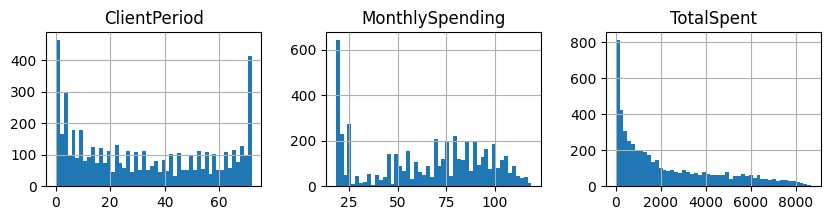

In [ ]:
data[num_cols].hist(figsize=(10, 2), bins=50, layout=(1, len(num_cols)))

Займемся теперь категориальными признаками.

In [ ]:
for item in cat_cols:
  print(data[item].value_counts(dropna=False),'\n') # Посмотрим на содержание категориальных признаков

Sex
Male      2655
Female    2627
Name: count, dtype: int64 

IsSeniorCitizen
0    4440
1     842
Name: count, dtype: int64 

HasPartner
No     2705
Yes    2577
Name: count, dtype: int64 

HasChild
No     3676
Yes    1606
Name: count, dtype: int64 

HasPhoneService
Yes    4761
No      521
Name: count, dtype: int64 

HasMultiplePhoneNumbers
No                  2511
Yes                 2250
No phone service     521
Name: count, dtype: int64 

HasInternetService
Fiber optic    2341
DSL            1800
No             1141
Name: count, dtype: int64 

HasOnlineSecurityService
No                     2612
Yes                    1529
No internet service    1141
Name: count, dtype: int64 

HasOnlineBackup
No                     2332
Yes                    1809
No internet service    1141
Name: count, dtype: int64 

HasDeviceProtection
No                     2317
Yes                    1824
No internet service    1141
Name: count, dtype: int64 

HasTechSupportAccess
No                     2604
Ye

Посмотрим на уникальные значения этих категориальных признаков.

In [ ]:
for item in cat_cols:
  print(item,data[item].unique(),'\n')

Sex ['Male' 'Female'] 

IsSeniorCitizen [0 1] 

HasPartner ['Yes' 'No'] 

HasChild ['Yes' 'No'] 

HasPhoneService ['Yes' 'No'] 

HasMultiplePhoneNumbers ['No' 'Yes' 'No phone service'] 

HasInternetService ['No' 'Fiber optic' 'DSL'] 

HasOnlineSecurityService ['No internet service' 'No' 'Yes'] 

HasOnlineBackup ['No internet service' 'No' 'Yes'] 

HasDeviceProtection ['No internet service' 'No' 'Yes'] 

HasTechSupportAccess ['No internet service' 'Yes' 'No'] 

HasOnlineTV ['No internet service' 'No' 'Yes'] 

HasMovieSubscription ['No internet service' 'No' 'Yes'] 

HasContractPhone ['One year' 'Two year' 'Month-to-month'] 

IsBillingPaperless ['No' 'Yes'] 

PaymentMethod ['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfer (automatic)'] 



Построим диаграммы для категориальных признаков. Их всего 16 - 4 строки по 4 столбца.

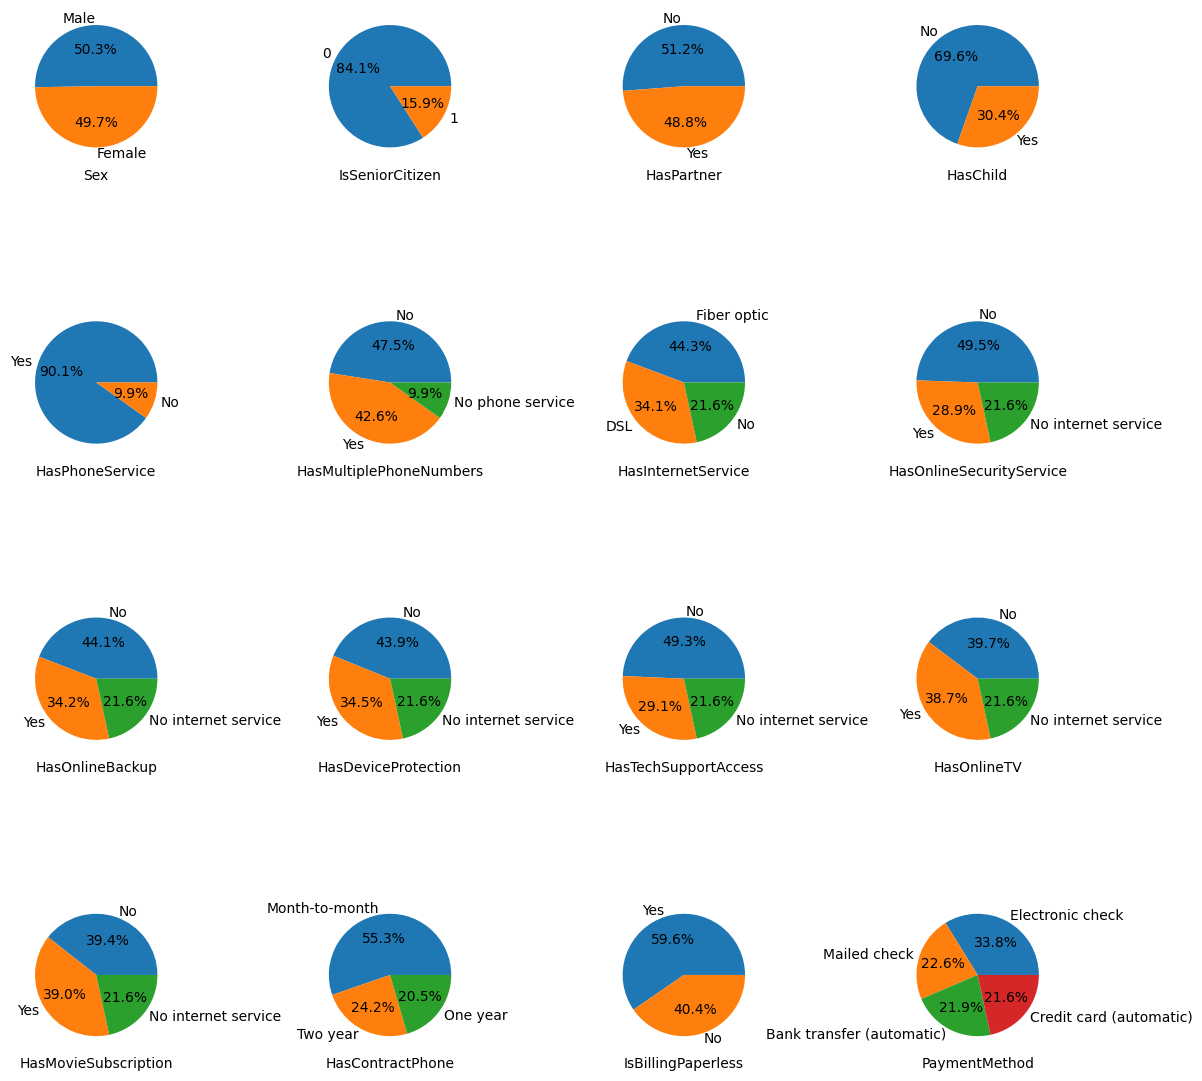

In [ ]:
fig, axes = plt.subplots((len(cat_cols) + 3) // 4, 4, figsize=(12, 12))
for column, ax in zip(cat_cols, axes.flatten()):
  counts = data[column].value_counts()
  ax.pie(counts.values, labels=counts.index, textprops={'fontsize': 10},
         autopct='%1.1f%%')
  ax.set_xlabel(column)
plt.tight_layout()
plt.show()

Далее построим диаграмму для целевого признака "Churn"

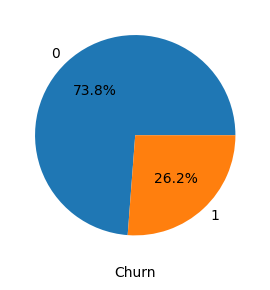

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(3, 3))
counts = data['Churn'].value_counts()
axes.pie(counts.values, labels=counts.index, textprops={'fontsize': 10},
         autopct='%1.1f%%')
axes.set_xlabel('Churn')
plt.tight_layout()
plt.show()

In [ ]:
data['Churn'].value_counts(dropna=False) # Выведем количество уникальных значений.

,count
Churn,
0,3898
1,1384


Видим, что данные в целевом признаке несколько несбалансированы. Однако степень несбалансированности можно считать не большой - соотношение меньше 20 и с большим запасом.

Далее сделаем ONE-HOT преобразование для категориальных признаков.

In [ ]:
data=pd.get_dummies(data, columns=cat_cols, drop_first=False, dtype=int)

Посмотрим теперь на полную числовую таблицу которую получили преобразованиями из первоначального сета data.

In [ ]:
data.describe(include = ['float64','int64']).T[['count', 'min', 'max']]

,count,min,max
ClientPeriod,5282.0,0.00,72.00
MonthlySpending,5282.0,18.25,118.75
TotalSpent,5282.0,0.00,8684.80
Churn,5282.0,0.00,1.00
Sex_Female,5282.0,0.00,1.00
Sex_Male,5282.0,0.00,1.00
IsSeniorCitizen_0,5282.0,0.00,1.00
IsSeniorCitizen_1,5282.0,0.00,1.00
HasPartner_No,5282.0,0.00,1.00
HasPartner_Yes,5282.0,0.00,1.00



НА ЭТОМ ЭТАПЕ РАБОТА С ТРЕНИРОВОЧНЫМ ДАТА СЕТОМ ЗАКОНЧЕНА. ВСЕ ОЦИФРОВАНО. НЕ СДЕЛАНА ЛИШЬ НОРМАЛИЗАЦИЯ. НО НОРМАЛИЗАЦИЮ МЫ СДЕЛАЕМ НИЖЕ ПЕРЕД ОБУЧЕНИЕМ МОДЕЛИ.

НИЖЕ ПРЕОБРАЗУЕМ ТЕСТОВЫЙ ДАТА СЕТ test АНАЛОГИЧНО ТОМУ КАК ВЫШЕ ПРЕОБРАЗОВЫВАЛИ ТРЕНИРОВОЧНЫЙ СЕТ (ONE-HOT).

In [ ]:
test=pd.get_dummies(test, columns=cat_cols, drop_first=False, dtype=int) # ONE-HOT


In [ ]:
test.describe(include = ['float64','int64']).T[['count', 'min', 'max']]

,count,min,max
ClientPeriod,1761.0,0.00,72.00
MonthlySpending,1761.0,18.55,117.35
TotalSpent,1761.0,0.00,8496.70
Sex_Female,1761.0,0.00,1.00
Sex_Male,1761.0,0.00,1.00
IsSeniorCitizen_0,1761.0,0.00,1.00
IsSeniorCitizen_1,1761.0,0.00,1.00
HasPartner_No,1761.0,0.00,1.00
HasPartner_Yes,1761.0,0.00,1.00
HasChild_No,1761.0,0.00,1.00


Убедимся что в данных не осталось None.

In [ ]:
data.isna().sum()

,0
ClientPeriod,0
MonthlySpending,0
TotalSpent,0
Churn,0
Sex_Female,0
Sex_Male,0
IsSeniorCitizen_0,0
IsSeniorCitizen_1,0
HasPartner_No,0
HasPartner_Yes,0


In [ ]:
test.isna().sum()

,0
ClientPeriod,0
MonthlySpending,0
TotalSpent,0
Sex_Female,0
Sex_Male,0
IsSeniorCitizen_0,0
IsSeniorCitizen_1,0
HasPartner_No,0
HasPartner_Yes,0
HasChild_No,0


## Применение линейных моделей

1) Обработаем данные для того, чтобы к ним можно было применить LogisticRegression. Т.е. отнормируем числовые признаки, а категориальные закодируем с помощью one-hot-encoding'а.

2) С помощью кроссвалидации или разделения на train/valid выборку протестируем разные значения гиперпараметра C и выберем лучший (можно тестировать С=100, 10, 1, 0.1, 0.01, 0.001) по метрике ROC-AUC.

Есои азделим на train/valid, то используем LogisticRegressionCV. Он сам при вызове .fit() подберет параметр С.


(более сложный вариант) Если будем использовать кроссвалидацию, то преобразования данных и LogisticRegression нужно соединить в один Pipeline с помощью make_pipeline. Потом pipeline надо передать в GridSearchCV. Для one-hot-encoding'a можно испльзовать комбинацию LabelEncoder + OneHotEncoder (сначала превращаем строчки в числа, а потом числа првращаем в one-hot вектора.)

In [ ]:
from sklearn.model_selection import train_test_split
# Оценка моделей
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict

# Метрики
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_auc_score, roc_curve

# Модели
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

Предлагается из линейных моделей рассмотреть LogisticRegression и для этой модели провести параметрическое исследование по параметру C.

Выберем оптимальную величину параметра "C" для LogisticRegression с нашими данными.

Сначала для целей обучения создадим сет данных X без целевой колонки "Churn" и сет y из целевой колонки "Churn". Кроме того отнормализуем X. И сразу разобъем данные на X_train, X_test, y_train, y_test в пропорции 0.8.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X = data.drop('Churn', axis=1)
y = data['Churn']

X_sc = scaler.fit_transform(X) # отнормировали данные. эту модель scaler мы используем ниже для нормирования уже тестовых данных test перед получением предсказания.

X_train, X_test, y_train, y_test = train_test_split(X_sc, y.values, train_size=0.8,
                                                    random_state=42)

Выполним кросс валидацию моделей. Для кросс валидации выберем 5 фолдов.

In [ ]:
ML=[100, 10, 1, 0.1, 0.01, 0.001] # Список величин параметра С для исследования на оптимальность.
grids = np.array(ML)
parameters = {'C': grids}

CV_model = GridSearchCV(estimator=LogisticRegression(),
                            param_grid=parameters,
                            cv=5,
                            scoring='roc_auc',
                            n_jobs=-1,
                            verbose=10)
CV_model.fit(X_train, y_train)
means = CV_model.cv_results_['mean_test_score']
print('Best')
print(CV_model.best_params_)
print('ROC_AUC')
print(means)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best
{'C': np.float64(10.0)}
ROC_AUC
[0.84880156 0.84880591 0.84856657 0.84743349 0.84572755 0.83980064]


Построим график полученной зависимости метрики roc_auc от параметра C.

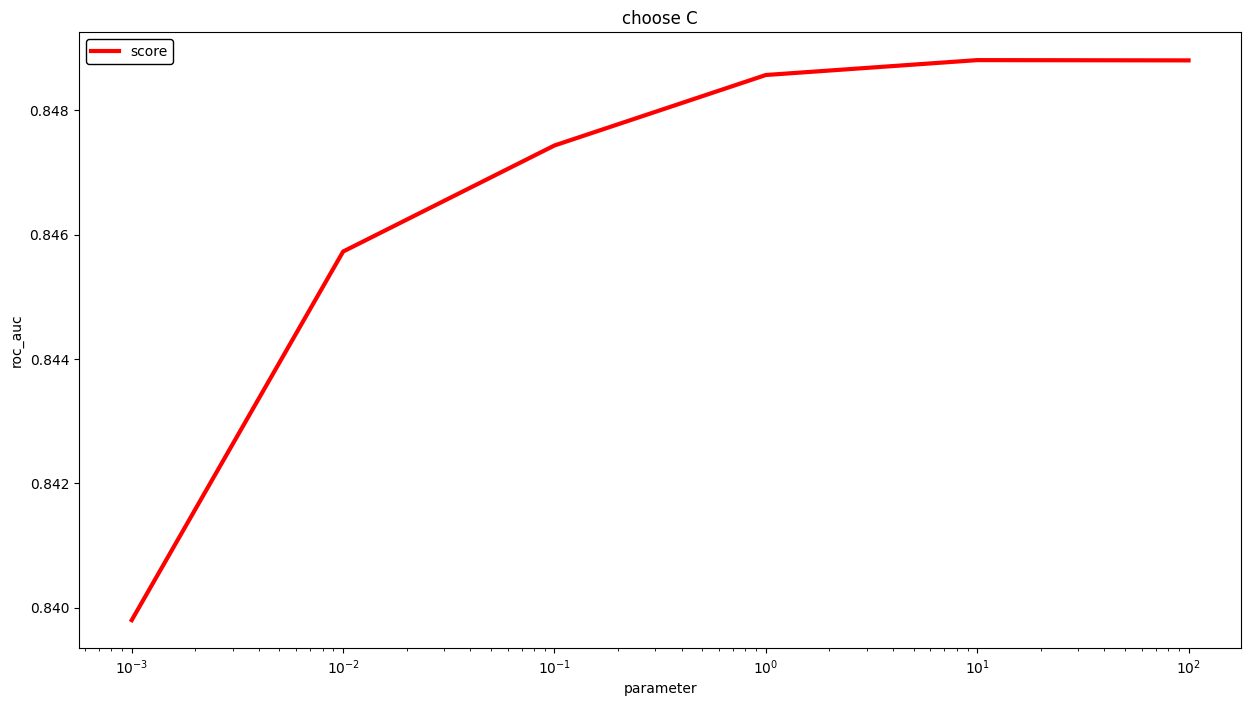

In [ ]:
plt.figure(figsize=(15,8))
plt.title('choose C')

plt.xscale('log')

plt.plot(grids, means, label='score', color='red', lw=3)

legend_box = plt.legend(framealpha=1).get_frame()
legend_box.set_facecolor("white")
legend_box.set_edgecolor("black")
plt.xlabel('parameter')
plt.ylabel('roc_auc')
plt.show()

Видим, что лучшая модель при С=10. ROC_AUC=0.84880591.

Далее при помощи полученной лучшей модели сделаем предсказание для тестовой выборки обучающего дата сета.

In [ ]:
best_model = CV_model.best_estimator_
y_pred_proba = best_model.predict_proba(X_test)[:, 1] # Получаем вероятности для положительного класса

# 6. Получаем результат качества предсказания по метрике roc_auc
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC AUC на тестовом наборе из обучающего data сета:", roc_auc)

ROC AUC на тестовом наборе из обучающего data сета: 0.827158042500531


Далее при помощи полученной лучшей модели на тестовом наборе test получим предсказание целевой переменной и отправим на проверку.

In [ ]:
submission = pd.read_csv('./submission.csv') # Скачали форму submission.csv

X_test_scaled = scaler.transform(test) # Не забываем отнормировать test по нормировочной модели полученной выше на тренировочных данным data.
y_pred=best_model.predict_proba(X_test_scaled)[:, 1]

submission['Churn'] =y_pred

submission.to_csv('./my_submission.csv', index=False)

ИТАК РЕЗУЛЬТАТОМ ВСЕЙ ЭТОЙ ОПИСАННОЙ ВЫШЕ РАБОТЫ СТАЛ ROC_AUC=0.

## Применение градиентного бустинга

Стоит попробовать градиентный бустинг. Часто градиентный бустинг с параметрами по умолчанию даст вам 80% результата за 0% усилий.

Мы будем использовать catboost, поэтому нам не надо кодировать категориальные признаки. Catboost сделает это сам (в .fit() надо передать cat_features=cat_cols). А численные признаки нормировать для моделей, основанных на деревьях не нужно.

1) Разделим выборку на train/valid. Протестируем catboost cо стандартными параметрами.

2) Протестируем разные значения параметров количества деревьев и learning_rate'а и выберем лучшую по метрике ROC-AUC комбинацию.

ИТАК ФИНАЛЬНО ПОПРОБУЕМ УЛУЧШИТЬ РЕЗУЛЬТАТ ПРИ ПОМОЩИ CATBOOST.
Для этого будем использовать ОРИГИНАЛЬНЫЕ данные без ONE HOT! (БУДЕМ ИСПОЛЬЗОВАТЬ ***_origin)

In [ ]:
# CatBoost умеет работать с категориальными признаками сам
# Бустеры
import catboost # документация: https://catboost.ai/docs
import xgboost

X = data_origin.drop('Churn', axis=1)
y = data_origin['Churn']
X_train_origin, X_test_origin, _, _ = train_test_split(X, y,
                                                       train_size=0.8,
                                                       random_state=42)

Будем искать лучшую модель по параметрам 'iterations', 'learning_rate', 'depth', 'l2_leaf_reg'. Надо сказать что поиск занимает продолжительное время - примерно 30 минут.

In [ ]:
#model = CatBoostClassifier(verbose=False, random_seed=42, loss_function='Logloss', eval_metric='AUC')  # Указываем loss_function и eval_metric

parameters = {'iterations': [500,600,700],
              'learning_rate': [0.01, 0.03, 0.1],
              'depth': [2,3,4],
              'l2_leaf_reg': [5, 7,8]}
model = catboost.CatBoostClassifier(random_seed=42, verbose=0, loss_function='Logloss', eval_metric='AUC')
# Запуск grid_search
grid_search = GridSearchCV(estimator=model,
                           param_grid=parameters,
                           scoring='roc_auc', #  Используем roc_auc или любую другую метрику scikit-learn
                           cv=5,
                           n_jobs=-1,
                           verbose=0)

grid_search.fit(X_train_origin, y_train, cat_features=cat_cols)

# Вывод результатов
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

# Оценка на тестовой выборке
best_model = grid_search.best_estimator_
y_pred_proba = best_model.predict_proba(X_test_origin)[:, 1]
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
print("Test ROC AUC:", test_roc_auc)

In [ ]:
y_train_predicted = best_model.predict_proba(X_train_origin)[:, 1]
y_test_predicted = y_pred_proba

Построим график полученных результатов.

In [ ]:
train_auc = roc_auc_score(y_train, y_train_predicted)
test_auc = roc_auc_score(y_test, y_test_predicted)

plt.figure(figsize=(10,7))
plt.plot(*roc_curve(y_train, y_train_predicted)[:2], label='train AUC={:.4f}'.format(train_auc))
plt.plot(*roc_curve(y_test, y_test_predicted)[:2], label='test AUC={:.4f}'.format(test_auc))
legend_box = plt.legend(fontsize='large', framealpha=1).get_frame()
legend_box.set_facecolor("white")
legend_box.set_edgecolor("black")
plt.plot(np.linspace(0,1,100), np.linspace(0,1,100))
plt.show()

При помощи полученной лучшей модели при Best parameters: {'depth': 3, 'iterations': 600, 'l2_leaf_reg': 7, 'learning_rate': 0.03} сделаем предсказания по тестовым данным запишем y_test_predicted в файл my_submission и отправим на проверку.

In [ ]:
y_test_predicted = best_model.predict_proba(test_origin)[:, 1]

# Предсказания

In [ ]:
submission = pd.read_csv('./submission.csv') # Скачали файл-форму

submission['Churn'] =y_test_predicted # Записали в дата сет колонку с предсказанием

submission.to_csv('./my_submission.csv', index=False) # записали дата сет в файл

ИТАК РЕЗУЛЬТАТ ПОЛУЧЕННЫЙ ПРИ ПОМОЩИ CATBOOST ROC_AUC=0.8482.

УБЕДИЛИСЬ ЧТО ПРАКТИЧЕСКИ БЕЗ ПРЕДВАРИТЕЛЬНОЙ ОБРАБОКИ ДАННЫХ МОЖНО ПОЛУЧИТЬ РЕЗУЛЬТАТ КОТОРЫЙ ПРЕВЫШАЕТ РЕЗУЛЬТАТ ПОЛУЧЕННЫЙ С ИСПОЛЬЗОВАНИЕМ БОЛЬШОЙ ПРЕДВАРИТЕЛЬНОЙ ОБРАБОТКИ ДАННЫХ И ИСПОЛЬЗОВАНИЕМ ДРУГИХ ЛИНЕЙНЫХ МОДЕЛЕЙ.